In [1]:
import pandas as pd

In [5]:
doi_csv = pd.read_csv(r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\retracted_compDataElec_DOI.csv")
dois = list(doi_csv["RetractionDOI"])

In [ ]:
import requests

# dois = [
#     '10.1371/journal.pone.0073381',
#     '10.1016/j.joi.2010.09.003',
#     # Add more DOIs as needed
# ]

for doi in dois:
    response = requests.get(f'https://api.openalex.org/works/https://doi.org/{doi}')
    if response.status_code == 200:
        data = response.json()
        # Process the data as needed
        print(data)
    else:
        print(f'Error retrieving data for DOI: {doi}')

In [3]:
import requests
import pandas as pd

# List of DOIs
# dois = [
#     '10.1371/journal.pone.0073381',
#     '10.1016/j.joi.2010.09.003'
# ]

# List to store results
data_list = []

# Fetch data from OpenAlex API
for doi in dois:
    url = f'https://api.openalex.org/works/https://doi.org/{doi}'
    response = requests.get(url)

    if response.status_code == 200:
        data = response.json()
        data_list.append({
            "DOI": doi,
            "Title": data.get("title", "N/A"),
            "Authors": ", ".join([author.get("author", {}).get("display_name", "Unknown") for author in data.get("authorships", [])]),
            "Year": data.get("publication_year", "N/A"),
            "Journal": data.get("primary_location", {}).get("source", {}).get("display_name", "N/A"),
            "Citations": data.get("cited_by_count", "N/A"),
            "OpenAlex_ID": data.get("id", "N/A")
        })
    else:
        data_list.append({
            "DOI": doi,
            "Title": "Error retrieving data",
            "Authors": "N/A",
            "Year": "N/A",
            "Journal": "N/A",
            "Citations": "N/A",
            "OpenAlex_ID": "N/A"
        })

# Convert to DataFrame
df = pd.DataFrame(data_list)

# Display DataFrame
import ace_tools as tools
tools.display_dataframe_to_user(name="OpenAlex Article Data", dataframe=df)


AttributeError: 'NoneType' object has no attribute 'get'

In [7]:
import requests
import pandas as pd

# List of DOIs
# dois = [
#     '10.1371/journal.pone.0073381',
#     '10.1016/j.joi.2010.09.003',
#     '10.7717/peerj.4375'
# ]

# List to store article information
articles = []

# Fetch data from OpenAlex API
for doi in dois:
    url = f'https://api.openalex.org/works/https://doi.org/{doi}'
    response = requests.get(url)

    if response.status_code == 200:
        data = response.json()

        # Handle cases where data might be None
        title = data.get('title', 'N/A')
        authors = data.get('authorships', [])
        authors_str = ', '.join([author['author']['display_name'] for author in authors if author.get('author')]) if authors else 'N/A'
        publication_year = data.get('publication_year', 'N/A')
        journal = data.get('host_venue', {}).get('display_name', 'N/A') if data.get('host_venue') else 'N/A'
        cited_by_count = data.get('cited_by_count', 'N/A')
        openalex_id = data.get('id', 'N/A')
        url_doi = data.get('doi', 'N/A')

        articles.append({
            'DOI': doi,
            'Title': title,
            'Authors': authors_str,
            'Publication Year': publication_year,
            'Journal': journal,
            'Cited By Count': cited_by_count,
            'OpenAlex ID': openalex_id,
            'URL': url_doi
        })
    else:
        articles.append({
            'DOI': doi,
            'Title': 'Error retrieving data',
            'Authors': 'N/A',
            'Publication Year': 'N/A',
            'Journal': 'N/A',
            'Cited By Count': 'N/A',
            'OpenAlex ID': 'N/A',
            'URL': 'N/A'
        })

# Create a DataFrame
df = pd.DataFrame(articles)

# Save to CSV
df.to_csv('openalex_articles.csv', index=False)

In [8]:
import requests
import pandas as pd

# List of DOIs
# dois = [
#     '10.1371/journal.pone.0073381',
#     '10.1016/j.joi.2010.09.003',
#     '10.7717/peerj.4375'
# ]

# Function to get citations and references for a DOI
def get_citation_details(doi):
    url = f'https://api.openalex.org/works/https://doi.org/{doi}'
    response = requests.get(url)

    if response.status_code == 200:
        data = response.json()

        # Extracting basic details
        title = data.get('title', 'N/A')
        openalex_id = data.get('id', 'N/A')

        # Getting list of works that this article cites
        references = data.get('referenced_works', [])

        # Getting the list of works that cite this article
        cited_by_url = f'https://api.openalex.org/works/{openalex_id}/cited_by'
        cited_by_response = requests.get(cited_by_url)
        cited_by_list = []

        if cited_by_response.status_code == 200:
            cited_by_data = cited_by_response.json()
            cited_by_list = [work['id'] for work in cited_by_data.get('results', [])]

        return {
            'DOI': doi,
            'Title': title,
            'OpenAlex ID': openalex_id,
            'Cited By': cited_by_list,
            'References': references
        }
    else:
        return {
            'DOI': doi,
            'Title': 'Error retrieving data',
            'OpenAlex ID': 'N/A',
            'Cited By': 'N/A',
            'References': 'N/A'
        }

# Fetch citation details for all DOIs
citation_data = [get_citation_details(doi) for doi in dois]

# Convert to DataFrame
df_citations = pd.DataFrame(citation_data)

# Save to CSV
df_citations.to_csv('citation_details.csv', index=False)

In [9]:
citeDetail = pd.read_csv('citation_details.csv')
retractedDataSet = pd.read_csv(r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\retracted_compDataElec.csv")

In [10]:
citeDetail

,DOI,Title,OpenAlex ID,Cited By,References
0,10.1155/2023/9865791,Retracted: An Architectural Framework for Heal...,https://openalex.org/W4388124931,[],['https://openalex.org/W3210178340']
1,10.1155/2023/9859342,Retracted: Clustering of Brain Tumor Based on ...,https://openalex.org/W4389127150,[],['https://openalex.org/W3198441341']
2,10.1155/2023/9849356,Retracted: Using a Blur Metric to Estimate Lin...,https://openalex.org/W4389381587,[],['https://openalex.org/W3210201227']
3,10.1155/2023/9831958,Retracted: Method of Cumulative Anomaly Identi...,https://openalex.org/W4389371056,[],['https://openalex.org/W4220766059']
4,10.1155/2023/9854302,Retracted: A Computer‐Aided Method for Digesti...,https://openalex.org/W4389398875,[],['https://openalex.org/W3206639986']
...,...,...,...,...,...
161,10.1007/978-3-319-42092-9_48,Retraction Note to: A Novel Voting Mathematica...,https://openalex.org/W2563871704,[],[]
162,10.1016/j.jvcir.2014.05.007,Retraction Note to “Pose invariant face recogn...,https://openalex.org/W2052373026,[],[]
163,10.1109/ICETC.2009.12,Notice of Retraction: Fuzzy PID Sliding Mode C...,https://openalex.org/W1961499357,[],"['https://openalex.org/W11567962', 'https://op..."
164,10.1142/S0219622013930012,STATEMENT OF RETRACTION — A LAGRANGIAN-BASED S...,https://openalex.org/W2075085261,[],[]


In [11]:
compDf = pd.read_csv(r"C:\Users\Parsa\Downloads\Merged_Retraction___Citation_Data.csv")

In [14]:
for index, row in compDf.iterrows():
    if(row['DOI'] == row['RetractionDOI']):
        continue
    else:
        print(index)

56
67
98


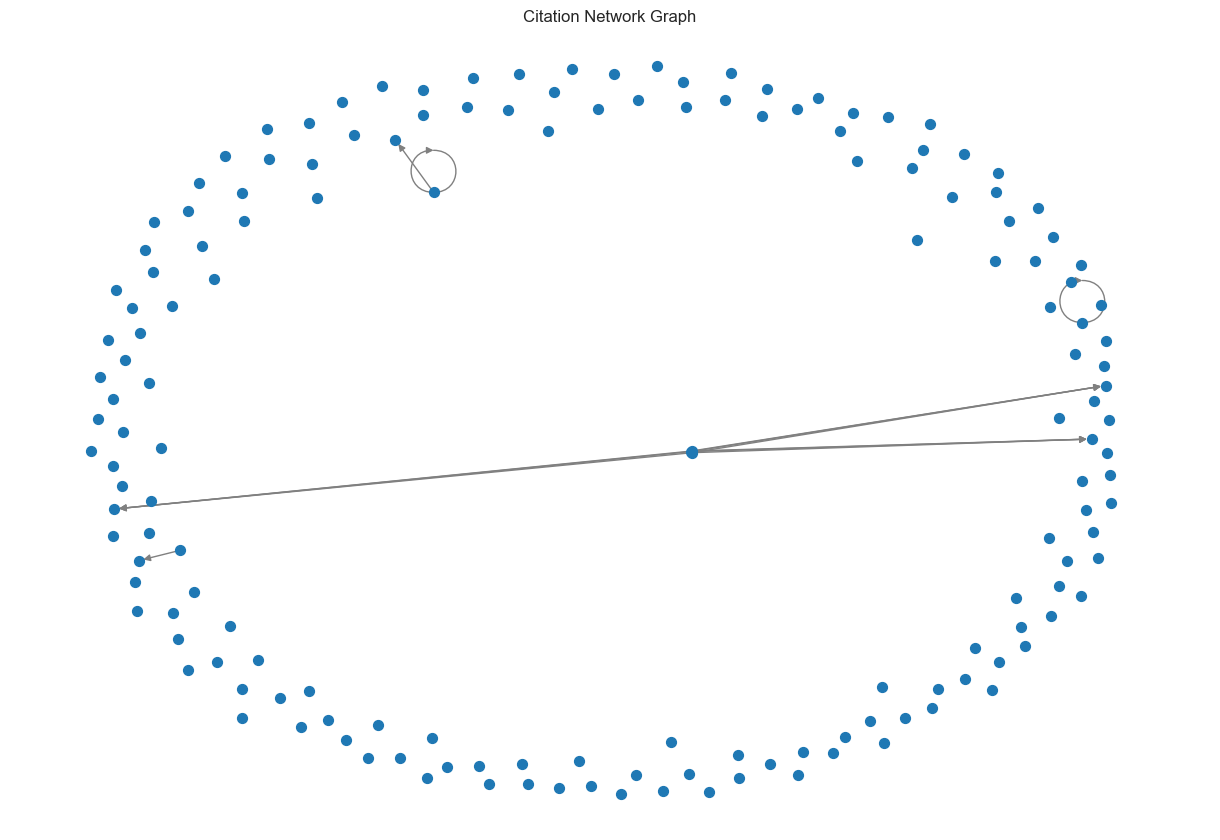

In [15]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Load the merged dataset
merged_file_path = r"C:\Users\Parsa\Downloads\Merged_Retraction___Citation_Data.csv"
df = pd.read_csv(merged_file_path)

# Create a directed graph
G = nx.DiGraph()

# Add nodes (articles) to the graph
for index, row in df.iterrows():
    article_id = row["OpenAlex ID"]
    if pd.notna(article_id):
        G.add_node(article_id, title=row.get("Title", "Unknown"))

# Add edges (citation relationships)
for index, row in df.iterrows():
    article_id = row["OpenAlex ID"]
    if pd.notna(article_id) and pd.notna(row["References"]):
        references = row["References"]

        # Handle case where references are stored as a string representation of a list
        if isinstance(references, str):
            references = references.strip("[]").replace("'", "").split(", ")

        for ref in references:
            if ref in G.nodes:
                G.add_edge(article_id, ref)

# Plot the citation graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)  # Layout for better visualization
nx.draw(G, pos, with_labels=False, node_size=50, edge_color="gray")
plt.title("Citation Network Graph")
plt.show()